In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("C:/Users/Dimple/Downloads/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
pd.options.display.max_columns = 500

In [ ]:
df.head()

In [ ]:
# Binary: Attrition, Gender, Over18, OverTime
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df['Over18'] = df['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
df.head()

In [ ]:
# One-Hot Encoding: Business Travel, Department, EducationFiled, JobRole, Marital Status

df.join(pd.get_dummies(df['BusinessTravel'])).drop('BusinessTravel',axis=1)
df.join(pd.get_dummies(df['Department'], prefix='Department')).drop('Department', axis=1)
df.join(pd.get_dummies(df['EducationField'], prefix='Education')).drop('EducationField', axis=1)
df.join(pd.get_dummies(df['JobRole'], prefix='Role')).drop('JobRole', axis=1)
df.join(pd.get_dummies(df['MaritalStatus'], prefix='Status')).drop('MaritalStatus', axis=1)

In [ ]:
df = df.map(lambda x: 1 if x is True else 0 if x is False else x)


In [ ]:
df.head()

In [ ]:
df = df.drop('EmployeeNumber', axis=1)

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(20,15))
plt.tight_layout()
plt.show

In [ ]:
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [ ]:
df.head()

In [ ]:
## Model training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = df.drop('Attrition', axis=1), df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_jobs=-1)

model.fit(X_train, y_train)

In [ ]:
model.score(X_test, y_test)

In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Dimple\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop useless columns
df = df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1)

# Features & target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(0)

X.head()


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
model.score(X_test, y_test)



0.8775510204081632

In [10]:
sorted_importances = dict(sorted (zip(model.feature_names_in_, model.feature_importances_), key=lambda x: x[1], reverse=True))

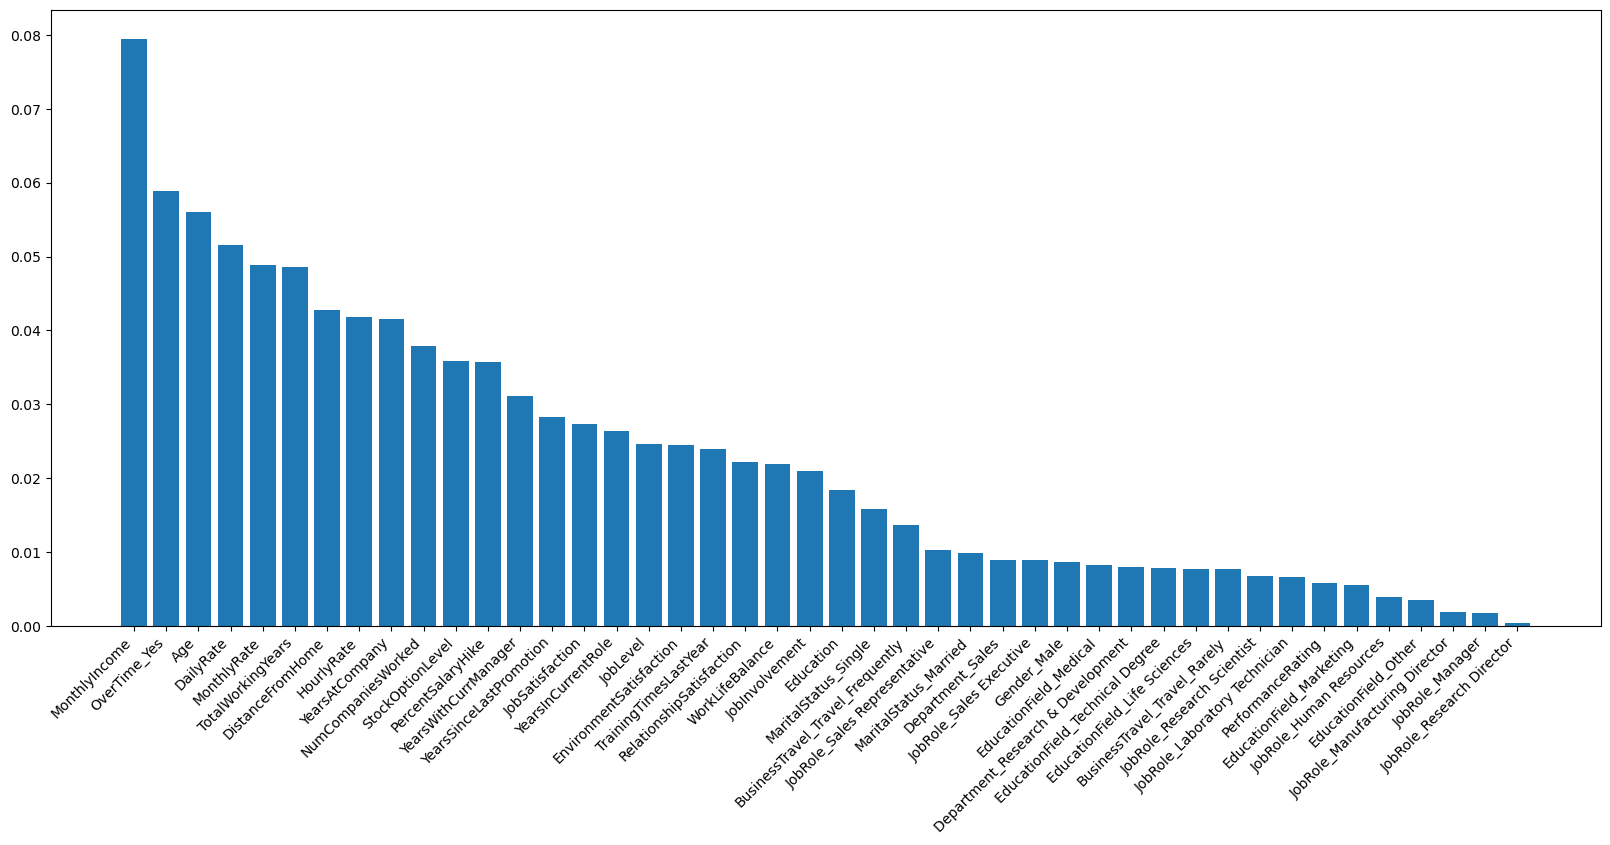

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
plt.bar(sorted_importances.keys(), sorted_importances.values())
plt.xticks(rotation=45, ha='right')

plt.show()